PROJET ML - VALIDATION CROISÉE

1. CHARGEMENT...
✅ Diplômes chargés: (2083, 9)
✅ Inscrits chargés: (19878, 6)

2. NETTOYAGE...
   Diplômes: 2032 lignes
   Inscrits: 17701 lignes

3. AGRÉGATION...

4. FUSION...
   Fusion: 400 lignes

5. CRÉATION DES FEATURES...
   Taux moyen: 26.52%

6. PRÉPARATION POUR LE ML...
   Features: 5
   Total observations: 400

7. VALIDATION CROISÉE RANDOM FOREST...
   Scores par fold: [0.93320196 0.98456832 0.9152812  0.98781063 0.61323357]
   Moyenne: 0.8868
   Écart-type: 0.1397

8. VALIDATION CROISÉE GRADIENT BOOSTING...
   Scores par fold: [0.91710696 0.97994106 0.84728903 0.99229206 0.75990198]
   Moyenne: 0.8993
   Écart-type: 0.0867

COMPARAISON DE STABILITÉ

Random Forest:
   R² moyen (CV): 0.8868 ± 0.1397

Gradient Boosting:
   R² moyen (CV): 0.8993 ± 0.0867

✅ Gradient Boosting est plus stable

10. GRAPHIQUE COMPARAISON...


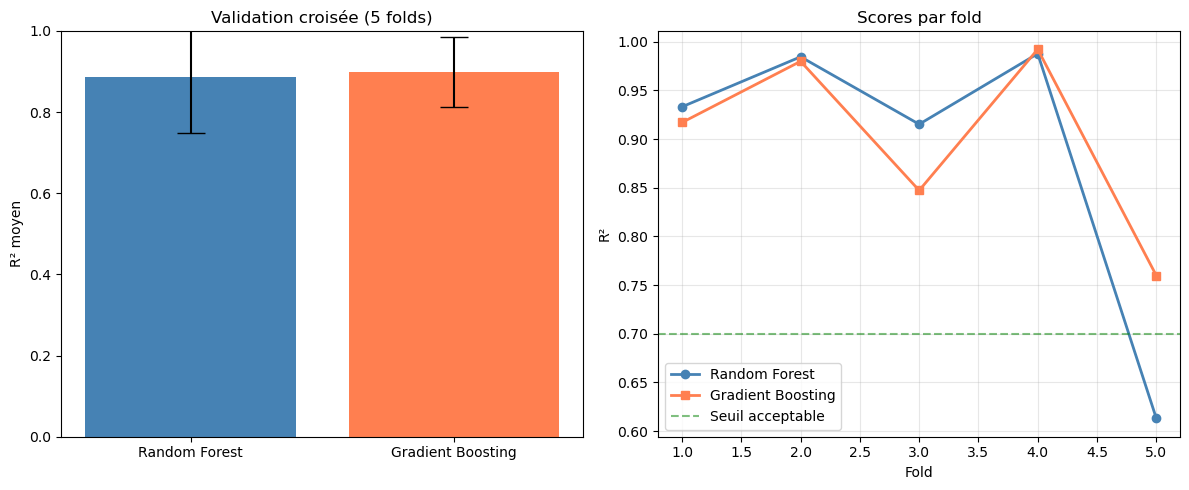


✅ VALIDATION CROISÉE TERMINÉE


In [10]:
# ============================================================
# PROJET ML - VALIDATION CROISÉE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("PROJET ML - VALIDATION CROISÉE")
print("="*70)

# ============================================================
# 1. CHARGEMENT
# ============================================================
print("\n1. CHARGEMENT...")

df_diplomes = pd.read_csv('../data/fact_diplomes.csv', sep=';', encoding='utf-8')
df_inscrits = pd.read_csv('../data/fact_inscrits.csv', sep=';', encoding='utf-8')

print(f"✅ Diplômes chargés: {df_diplomes.shape}")
print(f"✅ Inscrits chargés: {df_inscrits.shape}")

# ============================================================
# 2. NETTOYAGE
# ============================================================
print("\n2. NETTOYAGE...")
df_diplomes = df_diplomes.drop_duplicates().dropna()
df_inscrits = df_inscrits.drop_duplicates().dropna()
print(f"   Diplômes: {len(df_diplomes)} lignes")
print(f"   Inscrits: {len(df_inscrits)} lignes")

# ============================================================
# 3. AGRÉGATION
# ============================================================
print("\n3. AGRÉGATION...")
df_diplomes_agg = df_diplomes.groupby(['universite_code','etablissement_code','domain_code']).agg({
    'diplomes_M':'sum','diplomes_F':'sum','diplomes_total':'sum'
}).reset_index()

df_inscrits_2022 = df_inscrits[df_inscrits['annee'] == 2022].copy()
df_inscrits_2022['inscrits_total'] = df_inscrits_2022['inscrits_f'] + df_inscrits_2022['inscrits_m']
df_inscrits_agg = df_inscrits_2022.groupby(['code_universite','code_etablissement','code_domaine']).agg({
    'inscrits_f':'sum','inscrits_m':'sum','inscrits_total':'sum'
}).reset_index()

# ============================================================
# 4. FUSION
# ============================================================
print("\n4. FUSION...")
df_diplomes_agg = df_diplomes_agg.rename(columns={'universite_code':'univ_code','etablissement_code':'etab_code'})
df_inscrits_agg = df_inscrits_agg.rename(columns={'code_universite':'univ_code','code_etablissement':'etab_code','code_domaine':'domain_code'})
df = pd.merge(df_diplomes_agg, df_inscrits_agg, on=['univ_code','etab_code','domain_code'], how='inner')
print(f"   Fusion: {len(df)} lignes")

# ============================================================
# 5. CIBLE ET FEATURES
# ============================================================
print("\n5. CRÉATION DES FEATURES...")
df['taux_reussite'] = (df['diplomes_total'] / df['inscrits_total']).clip(0, 1)

df['ratio_feminisation'] = df['inscrits_f'] / df['inscrits_total']
df['log_taille'] = np.log1p(df['inscrits_total'])
df['efficacite_F'] = df['diplomes_F'] / (df['inscrits_f'] + 1)
df['efficacite_M'] = df['diplomes_M'] / (df['inscrits_m'] + 1)
df['ecart_genre'] = abs(df['efficacite_F'] - df['efficacite_M'])

print(f"   Taux moyen: {df['taux_reussite'].mean():.2%}")

# ============================================================
# 6. PRÉPARATION POUR LE ML
# ============================================================
print("\n6. PRÉPARATION POUR LE ML...")

features = ['ratio_feminisation', 'log_taille', 'efficacite_F', 'efficacite_M', 'ecart_genre']
X = df[features]
y = df['taux_reussite']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"   Features: {len(features)}")
print(f"   Total observations: {len(X_scaled)}")

# ============================================================
# 7. VALIDATION CROISÉE RANDOM FOREST
# ============================================================
print("\n7. VALIDATION CROISÉE RANDOM FOREST...")

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)

cv_scores_rf = cross_val_score(rf, X_scaled, y, cv=5, scoring='r2')
print(f"   Scores par fold: {cv_scores_rf}")
print(f"   Moyenne: {cv_scores_rf.mean():.4f}")
print(f"   Écart-type: {cv_scores_rf.std():.4f}")

# ============================================================
# 8. VALIDATION CROISÉE GRADIENT BOOSTING
# ============================================================
print("\n8. VALIDATION CROISÉE GRADIENT BOOSTING...")

gb = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42)

cv_scores_gb = cross_val_score(gb, X_scaled, y, cv=5, scoring='r2')
print(f"   Scores par fold: {cv_scores_gb}")
print(f"   Moyenne: {cv_scores_gb.mean():.4f}")
print(f"   Écart-type: {cv_scores_gb.std():.4f}")

# ============================================================
# 9. COMPARAISON DE STABILITÉ
# ============================================================
print("\n" + "="*70)
print("COMPARAISON DE STABILITÉ")
print("="*70)

print(f"\nRandom Forest:")
print(f"   R² moyen (CV): {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")

print(f"\nGradient Boosting:")
print(f"   R² moyen (CV): {cv_scores_gb.mean():.4f} ± {cv_scores_gb.std():.4f}")

if cv_scores_gb.std() < cv_scores_rf.std():
    print("\n✅ Gradient Boosting est plus stable")
else:
    print("\n✅ Random Forest est plus stable")

# ============================================================
# 10. GRAPHIQUE COMPARAISON
# ============================================================
print("\n10. GRAPHIQUE COMPARAISON...")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graphique 1: Comparaison des scores CV
modeles = ['Random Forest', 'Gradient Boosting']
scores_moyens = [cv_scores_rf.mean(), cv_scores_gb.mean()]
scores_std = [cv_scores_rf.std(), cv_scores_gb.std()]

axes[0].bar(modeles, scores_moyens, yerr=scores_std, color=['steelblue', 'coral'], capsize=10)
axes[0].set_ylabel('R² moyen')
axes[0].set_title('Validation croisée (5 folds)')
axes[0].set_ylim(0, 1)

# Graphique 2: Distribution des scores par fold
axes[1].plot(range(1, 6), cv_scores_rf, 'o-', label='Random Forest', color='steelblue', linewidth=2)
axes[1].plot(range(1, 6), cv_scores_gb, 's-', label='Gradient Boosting', color='coral', linewidth=2)
axes[1].axhline(y=0.7, color='green', linestyle='--', alpha=0.5, label='Seuil acceptable')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('R²')
axes[1].set_title('Scores par fold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("✅ VALIDATION CROISÉE TERMINÉE")
print("="*70)